In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix

df = pd.read_csv("amazon_sales_dataset.csv")

In [18]:
df.head()

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
0,1,2022-04-13,2637,Books,128.75,10,4,North America,UPI,3.5,443,115.88,463.52
1,2,2023-03-12,2300,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,1210.40
2,3,2022-09-28,3670,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,793.28
3,4,2022-04-17,2522,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,1264.64
4,5,2022-03-13,1717,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,806.72


In [19]:
df.describe()

,order_id,product_id,price,discount_percent,quantity_sold,rating,review_count,discounted_price,total_revenue
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,25000.500000,2986.848740,252.507260,13.340700,2.999400,2.996316,249.329280,218.886566,657.331475
std,14433.901067,1156.374535,143.025544,9.850694,1.415401,1.154295,144.251981,127.317681,526.223968
min,1.000000,1000.000000,5.010000,0.000000,1.000000,1.000000,0.000000,3.530000,3.840000
25%,12500.750000,1983.000000,127.840000,5.000000,2.000000,2.000000,125.000000,109.680000,240.320000
50%,25000.500000,2983.000000,252.970000,10.000000,3.000000,3.000000,250.000000,215.805000,505.410000
75%,37500.250000,3989.000000,376.335000,20.000000,4.000000,4.000000,374.000000,322.702500,968.970000
max,50000.000000,4999.000000,499.990000,30.000000,5.000000,5.000000,499.000000,499.910000,2499.550000


In [20]:
from sklearn.model_selection import train_test_split

X = df[["price","discount_percent","quantity_sold","rating","review_count"]]
y = df["total_revenue"]

In [21]:
df = df.fillna(0)

In [22]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [23]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()

model.fit(x_train, y_train)

RandomForestRegressor()

In [24]:
pred = model.predict(x_test)

In [25]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, pred)
print(r2)

0.9999973452061341


In [26]:
result = pd.DataFrame({"Real": y_test, "Predicted": pred})

result.head(10)

,Real,Predicted
33788,207.34,207.3232
7296,270.60,271.7636
34845,666.06,666.2548
31867,910.94,910.6210
23460,764.72,764.6686
16066,191.94,191.5760
45800,700.68,700.4376
49995,134.95,132.0185
30950,820.14,820.2482
47840,1670.90,1670.4170


In [27]:
importance = pd.Series(model.feature_importances_,index=X.columns)

importance.sort_values(ascending=False)

,0
price,0.523889
quantity_sold,0.445369
discount_percent,0.030737
review_count,0.000002
rating,0.000002


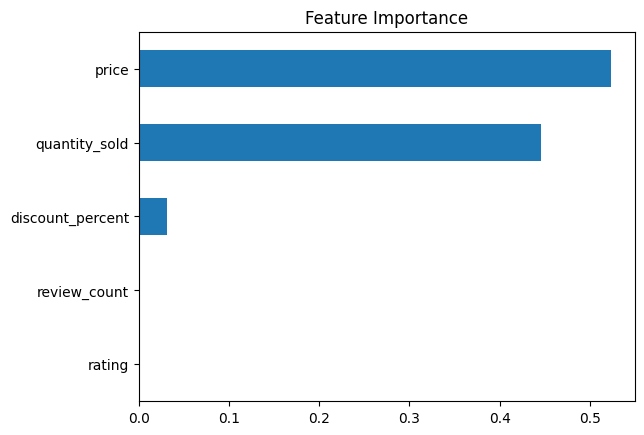

In [28]:
importance.sort_values().plot(kind="barh")
plt.title("Feature Importance")
plt.show()

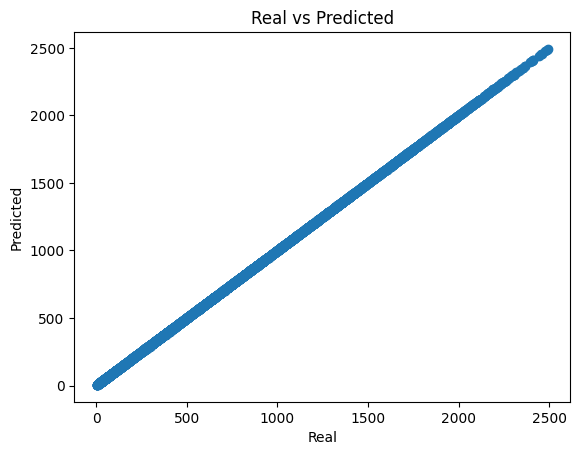

In [29]:
plt.scatter(y_test, pred)
plt.xlabel("Real")
plt.ylabel("Predicted")
plt.title("Real vs Predicted")
plt.show()

In [30]:
from  sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

r2 = r2_score(y_test, pred)
mae = mean_absolute_error(y_test, pred)
mse = mean_squared_error(y_test, pred)

result["error"] = result["Real"] - result["Predicted"]

result.sort_values("error", ascending=False).head(10)


,Real,Predicted,error
47386,405.20,395.6215,9.5785
29401,395.40,386.4935,8.9065
7625,295.65,287.4865,8.1635
14041,275.20,268.3730,6.8270
34000,279.80,273.4425,6.3575
45163,301.70,295.3785,6.3215
12066,2263.75,2257.4755,6.2745
24268,295.95,289.8430,6.1070
28897,891.90,886.0435,5.8565
8946,1917.50,1911.7265,5.7735


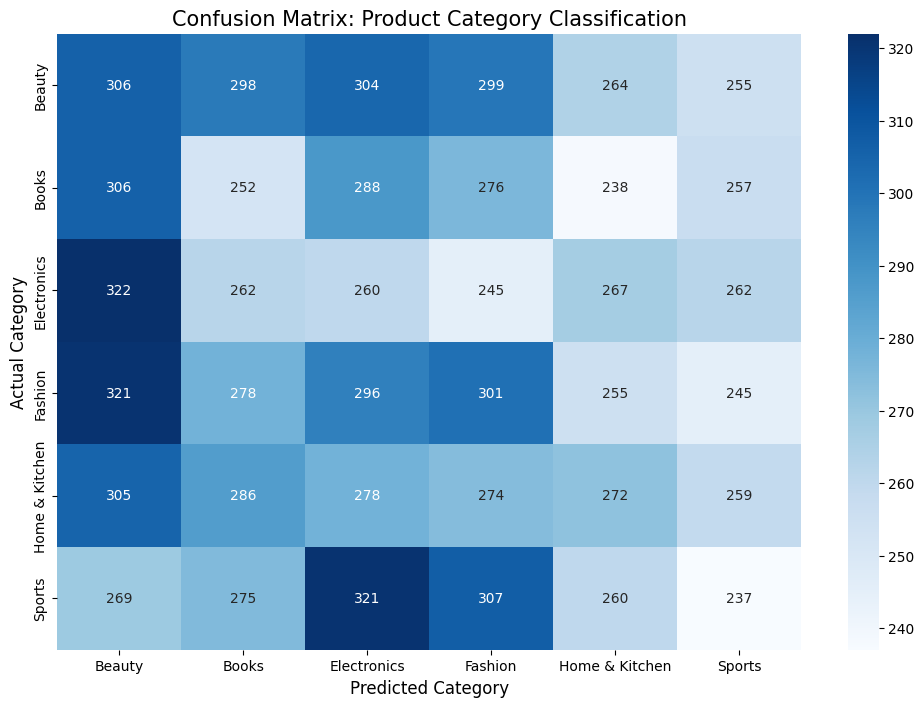

In [43]:
final_model = RandomForestClassifier(n_estimators=100, random_state=42)
final_model.fit(x_train, y_train)


y_pred = final_model.predict(x_test)


plt.figure(figsize=(12, 8))
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=final_model.classes_,
            yticklabels=final_model.classes_)

plt.title('Confusion Matrix: Product Category Classification', fontsize=15)
plt.xlabel('Predicted Category', fontsize=12)
plt.ylabel('Actual Category', fontsize=12)
plt.show()